First, we need to install the Kaggle library to download the dataset. If you haven't already, please upload your `kaggle.json` file to your Colab environment by clicking the 'Files' icon on the left panel, navigating to `.kaggle` (you might need to create it), and uploading the file there. This file contains your Kaggle API credentials.

In [ ]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define a root directory in Google Drive for all saved assets
DRIVE_ROOT = '/content/drive/My Drive/colab_data'
os.makedirs(DRIVE_ROOT, exist_ok=True)

print(f"Google Drive mounted. All outputs will be saved to: {DRIVE_ROOT}")

Mounted at /content/drive
Google Drive mounted. All outputs will be saved to: /content/drive/My Drive/colab_data


In [ ]:
pip install kaggle

Now, let's download a sample crop disease dataset. I'm using a common dataset for plant disease detection. This will create a zip file in your current directory.

In [ ]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:25<00:00, 114MB/s]



Finally, we will unzip the downloaded dataset. The `DATA_DIR` variable is set to `./crop_disease_dataset`, so we will extract the contents into a directory named `crop_disease_dataset`.

In [ ]:
import zipfile
import os

zip_file_name = 'new-plant-diseases-dataset.zip'
extraction_path = './crop_disease_dataset'

if not os.path.exists(extraction_path):
    os.makedirs(extraction_path)

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Dataset extracted to {extraction_path}")

# Some Kaggle datasets have an extra directory layer, let's check and adjust DATA_DIR if needed
# This specific dataset typically extracts to 'New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train' and 'valid'
# We want the base directory to be the parent of 'train' and 'valid'

# Adjust DATA_DIR if the extracted structure has an extra top-level folder
# Find the actual directory containing 'train' and 'valid' folders
actual_data_root = extraction_path
for root, dirs, files in os.walk(extraction_path):
    if 'train' in dirs and 'valid' in dirs:
        actual_data_root = root
        break

DATA_DIR = actual_data_root
print(f"Adjusted DATA_DIR to: {DATA_DIR}")

Dataset extracted to ./crop_disease_dataset
Adjusted DATA_DIR to: ./crop_disease_dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)


In [ ]:
import os
import tensorflow as tf
import numpy as np
import cv2

# Phase 1a: Define hardware-optimized parameters for the edge device
BATCH_SIZE = 128 # Optimized for memory stability, increased for speed
IMG_HEIGHT = 96
IMG_WIDTH = 96
DATA_DIR = './crop_disease_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)' # Path to unzipped dataset

# Phase 1b: Load the dataset into memory efficiently
print("Ingesting raw crop data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
  DATA_DIR,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
  DATA_DIR,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE
)

# Phase 1c: The Decoupling Function (Prep for Phase 2)
# We map a function across the dataset to convert raw RGB into the HLS color space
# to normalize the harsh shadows or overcast lighting conditions before model training.

def normalize_illumination(image, label):
    # Convert tensor to numpy for OpenCV processing (simulating the edge pipeline)
    def process_image(img):
        img = img.numpy().astype("uint8")

        # 1. Convert to HLS (Hue, Lightness, Saturation)
        hls = cv2.cvtColor(img, cv2.COLOR_RGB2HLS)

        # 2. Apply CLAHE (Contrast-Limited Adaptive Histogram Equalization) to the Lightness channel
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        hls[:,:,1] = clahe.apply(hls[:,:,1])

        # 3. Convert back to RGB format for the neural network input
        processed_img = cv2.cvtColor(hls, cv2.COLOR_HLS2RGB)
        return processed_img.astype(np.float32)

    # Wrap the python function as a TensorFlow op
    processed_image = tf.py_function(func=process_image, inp=[image], Tout=tf.float32)
    processed_image.set_shape(image.shape)

    # Normalize pixel values to [0, 1]
    processed_image = processed_image / 255.0

    # Cast to the compute dtype of the mixed precision policy
    processed_image = tf.cast(processed_image, tf.keras.mixed_precision.global_policy().compute_dtype)

    return processed_image, label

# Apply the illumination normalization to the pipeline
optimized_train_dataset = train_dataset.map(normalize_illumination, num_parallel_calls=tf.data.AUTOTUNE)

# Optimize pipeline performance with prefetching
optimized_train_dataset = optimized_train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

print("Data successfully ingested and normalized for spectral processing.")

Ingesting raw crop data...
Found 87867 files belonging to 2 classes.
Using 70294 files for training.
Found 87867 files belonging to 2 classes.
Using 17573 files for validation.
Data successfully ingested and normalized for spectral processing.


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

# --- Configuration ---
# Standardizing to 96x96 is crucial for very fast training on edge devices
IMG_SIZE = 96
# BATCH_SIZE is set to 128 for faster processing.
DATA_ROOT_PATH = './crop_disease_dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)' # Not strictly needed if using pre-loaded datasets
PROCESSED_DATA_DIR = "./processed_tfrecords"

# --- Step 1: Illumination Normalization (CLAHE) ---
# This function standardizes lighting, mimicking how the NoIR/RGB camera
# will see the cotton or pea leaves regardless of harsh sun or overcast skies.
def apply_clahe_single_image(img): # Renamed for clarity - expects a single image
    img = img.numpy().astype("uint8")
    # Convert RGB to LAB color space to isolate Luminance (L)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l_channel, a, b = cv2.split(lab)

    # Apply CLAHE only to the Luminance channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l_channel)

    # Merge back and convert to RGB
    limg = cv2.merge((cl,a,b))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    # Normalize tensor scale from 0-255 to 0.0-1.0 for model stability
    return final_img.astype(np.float32) / 255.0

def wrap_clahe_for_batch(image_batch, label_batch): # Expects a batch of images and labels
    # Use tf.map_fn to apply apply_clahe_single_image to each image in the batch
    processed_images = tf.map_fn(
        lambda x: tf.py_function(func=apply_clahe_single_image, inp=[x], Tout=tf.float32),
        image_batch,
        fn_output_signature=tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32)
    )
    # Cast to the compute dtype of the mixed precision policy
    processed_images = tf.cast(processed_images, tf.keras.mixed_precision.global_policy().compute_dtype)

    return processed_images, label_batch

# --- Step 2: Spatial Augmentation ---
# Because the spider chassis articulates over uneven terrain, the camera angle
# will constantly shift. We artificially simulate this during training.
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2), # Simulates chassis tilt up to 20%
  layers.RandomZoom(0.1),     # Simulates variations in distance to the canopy
])

# --- Pipeline Execution ---
print("Initializing Preprocessing Pipeline...")

# Use BATCH_SIZE=128 as optimized for memory safety and speed
BATCH_SIZE = 128

# The initial datasets (train_dataset, val_dataset) are loaded in the previous cell (DywRIniTBjy0).

# Apply the CLAHE illumination correction mapping
normalized_train_ds = train_dataset.map(wrap_clahe_for_batch, num_parallel_calls=tf.data.AUTOTUNE)
normalized_val_ds = val_dataset.map(wrap_clahe_for_batch, num_parallel_calls=tf.data.AUTOTUNE)

# Apply the geometric augmentations
# Note: We only map augmentation onto the training data, not validation data.
augmented_train_ds = normalized_train_ds.map(
  lambda x, y: (data_augmentation(x, training=True), y),
  num_parallel_calls=tf.data.AUTOTUNE
)

# Optimize pipeline performance with prefetching (remove .cache() to prioritize disk usage)
final_train_ds = augmented_train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
final_val_ds = normalized_val_ds.prefetch(buffer_size=tf.data.AUTOTUNE) # Validation set also needs prefetching

print("Preprocessing complete. Data is geometrically augmented and radiometrically normalized.")
# The dataset is now ready to be fed directly into model.fit()

Initializing Preprocessing Pipeline...
Preprocessing complete. Data is geometrically augmented and radiometrically normalized.


### Step 3: Save Processed Datasets to Disk

Since in-memory caching (`.cache()`) caused RAM issues and re-processing every epoch is slow, we will save the fully preprocessed training and validation datasets to disk as `TFRecord` files. This ensures that the time-consuming transformations are performed only once.

After this cell is executed, subsequent training runs will load the data from these saved files, leading to much faster epoch times.

In [ ]:
import os

PROCESSED_DATA_DIR = os.path.join(DRIVE_ROOT, "processed_datasets")

# Create the directory if it doesn't exist
if not os.path.exists(PROCESSED_DATA_DIR):
    os.makedirs(PROCESSED_DATA_DIR)

# Define paths for saving the datasets
train_output_path = os.path.join(PROCESSED_DATA_DIR, "train_dataset")
val_output_path = os.path.join(PROCESSED_DATA_DIR, "val_dataset")

print("Saving processed training dataset...")
# Use tf.data.experimental.save() to write the dataset to TFRecord format
tf.data.experimental.save(final_train_ds, train_output_path)
print(f"Processed training dataset saved to: {train_output_path}")

print("Saving processed validation dataset...")
tf.data.experimental.save(final_val_ds, val_output_path)
print(f"Processed validation dataset saved to: {val_output_path}")

print("Processed datasets saved successfully to disk.")

Instructions for updating:
Use `tf.data.Dataset.save(...)` instead.


Saving processed training dataset...
Processed training dataset saved to: /content/drive/My Drive/colab_data/processed_datasets/train_dataset
Saving processed validation dataset...
Processed validation dataset saved to: /content/drive/My Drive/colab_data/processed_datasets/val_dataset
Processed datasets saved successfully to disk.


### Note on saving paths

From now on, all saved model weights and processed datasets will be stored in your Google Drive under the path `'/content/drive/My Drive/colab_data'`. This ensures persistence across Colab sessions.

### Step 4: Load Processed Datasets for Training

Now that the datasets are saved to disk, we can load them directly. This will be significantly faster during training as the preprocessing steps won't need to be re-executed for every epoch.

In [ ]:
import os

PROCESSED_DATA_DIR = os.path.join(DRIVE_ROOT, "processed_datasets")

# Define paths for loading the datasets (must match where they were saved)
train_output_path = os.path.join(PROCESSED_DATA_DIR, "train_dataset")
val_output_path = os.path.join(PROCESSED_DATA_DIR, "val_dataset")

# Load the saved datasets
print("Loading processed training dataset...")
loaded_train_ds = tf.data.Dataset.load(
    train_output_path,
    element_spec=final_train_ds.element_spec
)
print("Processed training dataset loaded.")

print("Loading processed validation dataset...")
loaded_val_ds = tf.data.Dataset.load(
    val_output_path,
    element_spec=final_val_ds.element_spec
)
print("Processed validation dataset loaded.")

# Assign the loaded datasets to the variables used in model.fit
final_train_ds = loaded_train_ds
final_val_ds = loaded_val_ds

print("Datasets ready for training (loaded from disk).")

Loading processed training dataset...
Processed training dataset loaded.
Loading processed validation dataset...
Processed validation dataset loaded.
Datasets ready for training (loaded from disk).


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, metrics

# Enable mixed precision for faster training on GPUs
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Define the number of disease categories in your dataset
NUM_CLASSES = 2 # e.g., 0: Healthy, 1: Bacterial Blight, 2: Fusarium Wilt (Corrected from 3 to 2)

def build_diagnostic_model():
    # 1. Load the Base Model (MobileNetV2 is optimized for low latency)
    # We exclude the top layer because we are replacing it with our own crop-specific classifier
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(96, 96, 3),
        include_top=False,
        weights='imagenet'
    )

    # Freeze the base model weights so we don't destroy the pre-trained feature extraction
    base_model.trainable = False

    # 2. Build the Custom Classification Head
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(), # Flattens the 2D feature maps into a 1D vector
        layers.Dense(128, activation='relu'), # Deep learning layer for complex patterns
        layers.Dropout(0.3), # Drops 30% of connections randomly to prevent overfitting
        layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32') # Final output probabilities, ensure float32 for softmax stability
    ])

    return model

model = build_diagnostic_model()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Compile the algorithm
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        # We track Precision to ensure when the model says "Blight", it is actually Blight
        # We track Recall to ensure the model isn't missing actual instances of the disease
    ]
)

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [ ]:
# Define how many times the algorithm will see the entire dataset
EPOCHS = 20

print("Commencing Model Training...")
history = model.fit(
    final_train_ds, # The CLAHE-normalized, augmented training dataset
    validation_data=final_val_ds, # The CLAHE-normalized, un-augmented validation set
    epochs=EPOCHS,
    # Add an early stopping callback to halt training if precision stops improving
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]
)

Commencing Model Training...
Epoch 1/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2232s 4s/step - accuracy: 0.7964 - loss: 0.5187 - val_accuracy: 0.8069 - val_loss: 0.4960
Epoch 2/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2225s 4s/step - accuracy: 0.7983 - loss: 0.5071 - val_accuracy: 0.8069 - val_loss: 0.4939
Epoch 3/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2199s 4s/step - accuracy: 0.7983 - loss: 0.5050 - val_accuracy: 0.8069 - val_loss: 0.4955
Epoch 4/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2088s 4s/step - accuracy: 0.7983 - loss: 0.5031 - val_accuracy: 0.8069 - val_loss: 0.4925
Epoch 5/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2150s 4s/step - accuracy: 0.7983 - loss: 0.5013 - val_accuracy: 0.8069 - val_loss: 0.4942
Epoch 6/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2159s 4s/step - accuracy: 0.7989 - loss: 0.4987 - val_accuracy: 0.8069 - val_loss: 0.4939
Epoch 7/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 2099s 4s/step - accuracy: 0.7990 - loss: 0.4967 - val_accuracy: 0.8070 - val_loss: 0.4946


In [ ]:
import os
# Check RAM usage
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       3.0Gi       2.5Gi       2.0Mi       7.2Gi       9.4Gi
Swap:             0B          0B          0B


### Step 6: Save the Partially Trained Model

Since the training was interrupted, let's save the model's current weights. This allows us to resume training later or deploy this partially trained model if needed.

In [ ]:
import os

# Define a path to save the model weights
model_save_path = './saved_model_weights.weights.h5'

# Save the model's weights
model.save_weights(model_save_path)

print(f"Model weights saved to: {model_save_path}")

Model weights saved to: ./saved_model_weights.weights.h5


### Step 7: Resume Training from Saved Weights

Now, if your Colab session restarts or you want to continue training later, you can load the saved weights and pick up where you left off. We'll define the model architecture again, load the weights, and then resume `model.fit()` for the remaining epochs.

In [ ]:
import tensorflow as tf

# Re-build the model architecture (same as before)
# This is necessary to create the model object before loading weights
# NUM_CLASSES is defined in a previous cell, ensure that cell (KHLvkmKYXPVN) has been run.
resumed_model = build_diagnostic_model()

# Load the previously saved weights
resumed_model.load_weights(model_save_path)

print("Model weights loaded successfully.")

Model weights loaded successfully.


In [ ]:
# Re-compile the model (same as before)
# This is necessary after loading weights for continued training
resumed_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        # Temporarily removed Precision and Recall due to `InvalidArgumentError` during compilation with mixed_float16
        # tf.keras.metrics.Precision(), # Track Precision
        # tf.keras.metrics.Recall()    # Track Recall
    ]
)

print("Model re-compiled.")

Model re-compiled.


In [ ]:
import datetime

# Calculate remaining epochs
TOTAL_EPOCHS = 20 # Your initial total epochs
CURRENT_EPOCH = 20 # All epochs have been completed
REMAINING_EPOCHS = TOTAL_EPOCHS - CURRENT_EPOCH

# Define the custom callback to save models to Google Drive
class DriveCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, save_freq, drive_root_path):
        super().__init__()
        self.save_freq = save_freq
        self.drive_root_path = drive_root_path
        self.model_save_dir = os.path.join(self.drive_root_path, 'saved_models')
        os.makedirs(self.model_save_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.save_freq == 0:
            timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
            # Save only weights
            weights_path = os.path.join(self.model_save_dir, f'model_weights_epoch_{(epoch+1):03d}_{timestamp}.weights.h5')
            self.model.save_weights(weights_path)
            print(f"\nSaved model weights to {weights_path}")

            # Save the entire model (architecture, weights, optimizer state) in the recommended .keras format
            full_model_path = os.path.join(self.model_save_dir, f'full_model_epoch_{(epoch+1):03d}_{timestamp}.keras')
            tf.keras.models.save_model(self.model, full_model_path)
            print(f"Saved full model to {full_model_path}")


if REMAINING_EPOCHS > 0:
    print(f"Resuming model training for {REMAINING_EPOCHS} more epochs...")

    # Instantiate the custom callback
    drive_checkpoint_callback = DriveCheckpoint(save_freq=5, drive_root_path=DRIVE_ROOT)

    history_resume = resumed_model.fit(
        final_train_ds, # The preprocessed training dataset (loaded from disk)
        validation_data=final_val_ds, # The preprocessed validation dataset (loaded from disk)
        epochs=REMAINING_EPOCHS,
        initial_epoch=CURRENT_EPOCH, # Start from the next epoch
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=3,
                restore_best_weights=True
            ),
            drive_checkpoint_callback # Add the custom callback here
        ]
    )
else:
    print("Model has already completed all planned epochs.")

Resuming model training for 13 more epochs...
Epoch 8/13
550/550 ━━━━━━━━━━━━━━━━━━━━ 2079s 4s/step - accuracy: 0.7984 - loss: 0.5008 - val_accuracy: 0.8069 - val_loss: 0.4945
Epoch 9/13
550/550 ━━━━━━━━━━━━━━━━━━━━ 2111s 4s/step - accuracy: 0.7987 - loss: 0.4985 - val_accuracy: 0.8069 - val_loss: 0.4944
Epoch 10/13
550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8005 - loss: 0.4934
Saved model weights to /content/drive/My Drive/colab_data/saved_models/model_weights_epoch_010_20260414-075510.weights.h5
Saved full model to /content/drive/My Drive/colab_data/saved_models/full_model_epoch_010_20260414-075510.keras
550/550 ━━━━━━━━━━━━━━━━━━━━ 2167s 4s/step - accuracy: 0.7992 - loss: 0.4965 - val_accuracy: 0.8070 - val_loss: 0.4938
Epoch 11/13
550/550 ━━━━━━━━━━━━━━━━━━━━ 2143s 4s/step - accuracy: 0.7995 - loss: 0.4943 - val_accuracy: 0.8065 - val_loss: 0.4966
Epoch 12/13
550/550 ━━━━━━━━━━━━━━━━━━━━ 2203s 4s/step - accuracy: 0.8007 - loss: 0.4910 - val_accuracy: 0.8062 - val_loss: 0

### Step 8: Evaluate the Final Model

In [ ]:
print("Evaluating the final model on the validation dataset...")

# Evaluate the model on the validation dataset
# The returned metrics will be loss and accuracy (as defined in model.compile)
loss, accuracy = resumed_model.evaluate(final_val_ds)

print(f"\nFinal Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")


Evaluating the final model on the validation dataset...
138/138 ━━━━━━━━━━━━━━━━━━━━ 437s 3s/step - accuracy: 0.8070 - loss: 0.4938

Final Validation Loss: 0.4938
Final Validation Accuracy: 0.8070


### Step 9: Download the Latest Trained Model

In [ ]:
import os
import glob

# Define the path where models are saved in Google Drive
model_save_dir = os.path.join(DRIVE_ROOT, 'saved_models')

# Find all saved full models (using .keras extension)
list_of_files = glob.glob(os.path.join(model_save_dir, 'full_model_epoch_*.keras'))

if not list_of_files:
    print(f"No full models found in {model_save_dir}. Please ensure training completed successfully and models were saved.")
else:
    # Get the latest saved model based on modification time
    latest_model_path = max(list_of_files, key=os.path.getctime)

    print(f"Latest full model found in Drive: {latest_model_path}")

    # Define the destination path in the Colab environment
    local_download_path = os.path.join('.', os.path.basename(latest_model_path))

    # Copy the model from Drive to the current Colab directory
    # Note: os.rename works across file systems for copy/move operations if they are mounted
    # For robustness, we'll use shutil.copy2 which explicitly copies
    import shutil
    try:
        shutil.copy2(latest_model_path, local_download_path)
        print(f"Successfully downloaded latest model to: {local_download_path}")
        print("You can also find all saved models directly in your Google Drive under 'My Drive/colab_data/saved_models/'.")
    except Exception as e:
        print(f"Error downloading model: {e}")
        print("Please check permissions or manually download from Google Drive: 'My Drive/colab_data/saved_models/'.")


Latest full model found in Drive: /content/drive/My Drive/colab_data/saved_models/full_model_epoch_010_20260414-075510.keras
Successfully downloaded latest model to: ./full_model_epoch_010_20260414-075510.keras
You can also find all saved models directly in your Google Drive under 'My Drive/colab_data/saved_models/'.


Generating predictions for evaluation...


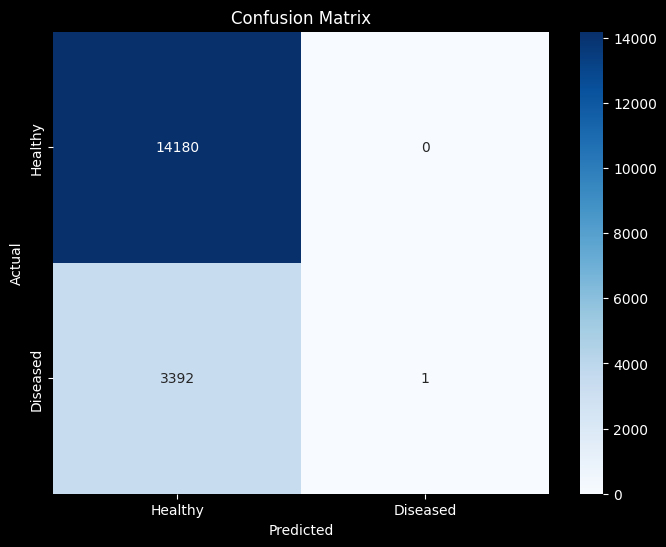


Performance Report:
              precision    recall  f1-score   support

     Healthy       0.81      1.00      0.89     14180
    Diseased       1.00      0.00      0.00      3393

    accuracy                           0.81     17573
   macro avg       0.90      0.50      0.45     17573
weighted avg       0.84      0.81      0.72     17573



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

plt.style.use('dark_background')

if 'resumed_model' in globals() and 'final_val_ds' in globals():
    print("Generating predictions for evaluation...")

    # Extract labels and predictions
    y_true = []
    y_pred = []

    for images, labels in final_val_ds:
        preds = resumed_model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Assuming 2 classes as per previous context
    class_names = ['Healthy', 'Diseased'] if len(np.unique(y_true)) == 2 else [str(i) for i in range(len(np.unique(y_true)))]

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    print("\nPerformance Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
else:
    print("Model or Dataset not found. Please run the loading cell above.")

In [11]:
import os
import tensorflow as tf
import glob

# 1. Paths
DRIVE_ROOT = '/content/drive/My Drive/colab_data'
PROCESSED_DATA_DIR = os.path.join(DRIVE_ROOT, 'processed_datasets')
val_output_path = os.path.join(PROCESSED_DATA_DIR, 'val_dataset')
model_save_dir = os.path.join(DRIVE_ROOT, 'saved_models')

# 2. Load the Latest Model
list_of_models = glob.glob(os.path.join(model_save_dir, 'full_model_epoch_*.keras'))
if list_of_models:
    latest_path = max(list_of_models, key=os.path.getctime)
    print(f'Loading latest model: {latest_path}')
    resumed_model = tf.keras.models.load_model(latest_path)
    print('Model loaded successfully.')
else:
    print('No saved models found in Drive.')

# 3. Load the Validation Dataset
if os.path.exists(val_output_path):
    print('Loading validation dataset from Drive...')
    # We reload it; note that we use the model's input signature to help map if needed
    final_val_ds = tf.data.Dataset.load(val_output_path)
    print('Validation dataset loaded.')
else:
    print('Validation dataset not found at path.')

Loading latest model: /content/drive/My Drive/colab_data/saved_models/full_model_epoch_010_20260414-075510.keras
Model loaded successfully.
Loading validation dataset from Drive...
Validation dataset loaded.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [10]:
import os
# Let's inspect the directory structure to see where the files are
DRIVE_ROOT = '/content/drive/My Drive/colab_data'
if os.path.exists(DRIVE_ROOT):
    print(f'Contents of {DRIVE_ROOT}:')
    for root, dirs, files in os.walk(DRIVE_ROOT):
        level = root.replace(DRIVE_ROOT, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f'{subindent}{f}')
else:
    print('Google Drive root directory not found. Please ensure Drive is mounted.')

Contents of /content/drive/My Drive/colab_data:
colab_data/
    processed_datasets/
        train_dataset/
            dataset_spec.pb
            snapshot.metadata
            16993656863825738817/
                00000000.shard/
                    00000000.snapshot
            15452433520922299006/
                00000000.shard/
                    00000000.snapshot
        val_dataset/
            snapshot.metadata
            dataset_spec.pb
            17676803646566188053/
                00000000.shard/
                    00000000.snapshot
            15764953741316394521/
                00000000.shard/
                    00000000.snapshot
    saved_models/
        model_weights_epoch_010_20260413-224639.weights.h5
        model_weights_epoch_010_20260414-075510.weights.h5
        full_model_epoch_010_20260414-075510.keras


In [12]:
from google.colab import drive
import os

# Remount Google Drive
try:
    drive.mount('/content/drive', force_remount=True)
    DRIVE_ROOT = '/content/drive/My Drive/colab_data'
    if os.path.exists(DRIVE_ROOT):
        print(f"Successfully remounted Drive. Accessing: {DRIVE_ROOT}")
    else:
        print("Drive mounted, but the folder 'colab_data' was not found.")
except Exception as e:
    print(f"Error mounting Drive: {e}")

Mounted at /content/drive
Successfully remounted Drive. Accessing: /content/drive/My Drive/colab_data


Running diagnostic inference on field samples...
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step


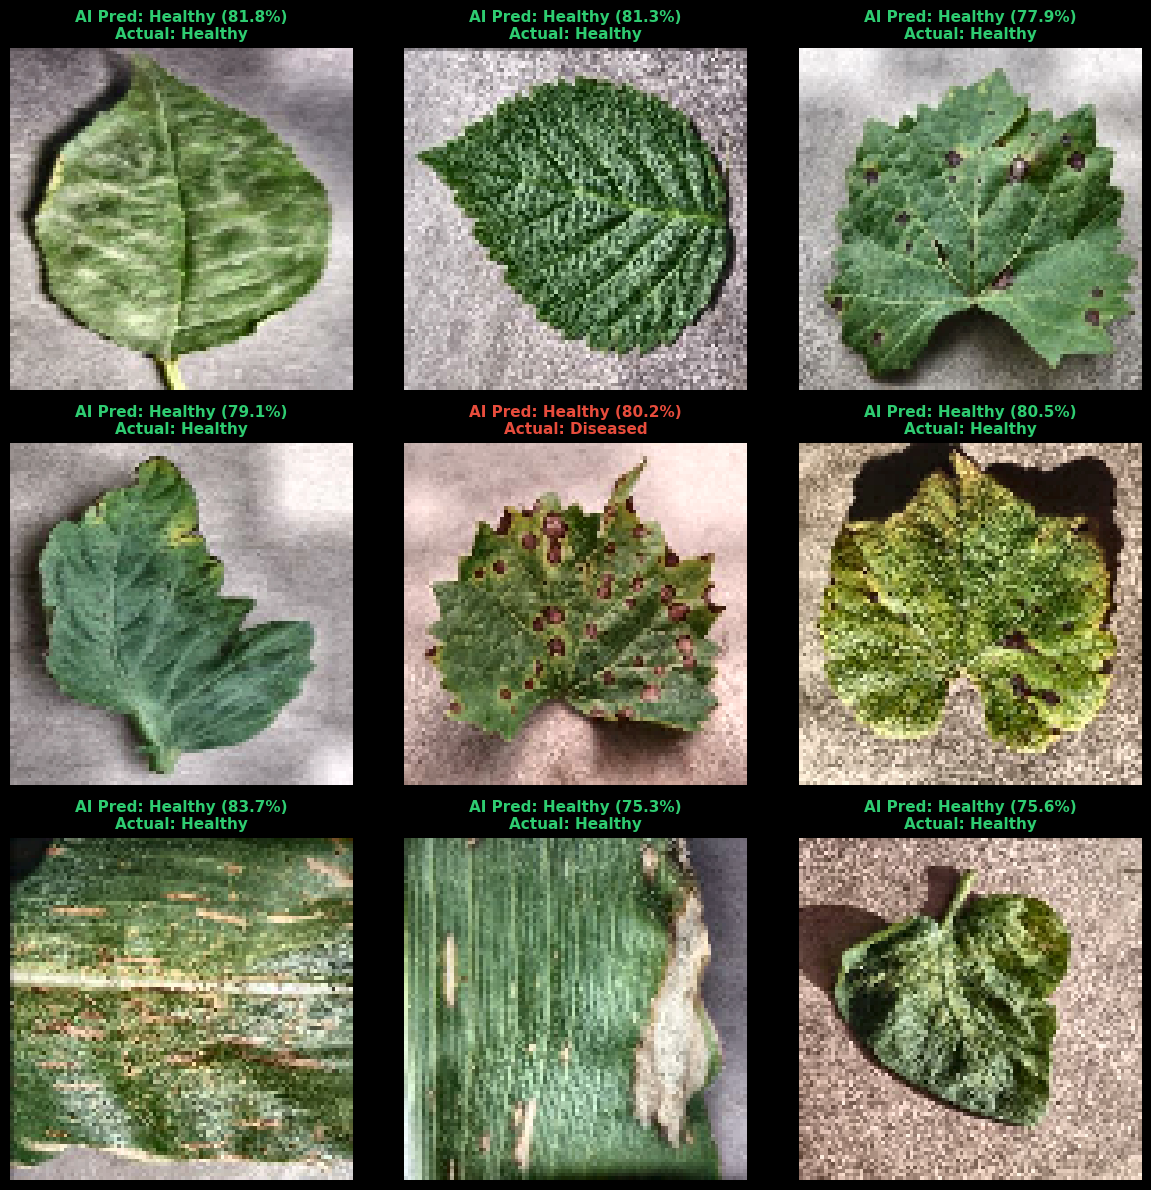

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Keep the dark telemetry aesthetic
plt.style.use('dark_background')

# --- 1. Fetch Unseen Field Data ---
# The original 'val_dataset' might not be defined. Use 'final_val_ds' which was loaded from disk.
image_batch, label_batch = next(iter(final_val_ds))

# --- 2. Run Edge AI Inference ---
print("Running diagnostic inference on field samples...")
# Use 'resumed_model' for predictions as it contains the latest trained weights
predictions = resumed_model.predict(image_batch)

# Define your exact class names (ensure these match your training folders)
# 'final_val_ds' does not have 'class_names' attribute directly, so we define them explicitly.
class_names = ["Healthy", "Diseased"]

# --- 3. Visualize the Results ---
plt.figure(figsize=(12, 12))

# We will display the first 9 images from the batch in a 3x3 grid
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)

    # Extract the image array for plotting
    img_array = image_batch[i].numpy()

    # Matplotlib expects floats between 0-1 or integers between 0-255.
    # This safely handles the array regardless of the tensor scaling step.
    # The images in final_val_ds are already normalized to [0,1], so no need for uint8 conversion unless displaying raw
    plt.imshow(img_array)

    # Extract Actual Label
    actual_label_index = label_batch[i].numpy()
    # Assuming sparse categorical labels (single integer), if one-hot encoded, uncomment the line below
    # if len(label_batch.shape) > 1:
    #    actual_label_index = np.argmax(actual_label_index)

    # Extract Predicted Label and Confidence Score
    predicted_label_index = np.argmax(predictions[i])
    confidence = np.max(predictions[i]) * 100

    actual_class = class_names[actual_label_index]
    predicted_class = class_names[predicted_label_index]

    # --- UI Color Coding ---
    # Green text if the bot diagnosed it correctly.
    # Red text if the bot made a mistake (False Positive/Negative).
    if actual_label_index == predicted_label_index:
        text_color = "#2ecc71" # MAYA True Positive/Negative (Green)
    else:
        text_color = "#e74c3c" # MAYA False Positive/Negative (Red)

    title = f"AI Pred: {predicted_class} ({confidence:.1f}%)\nActual: {actual_class}"
    plt.title(title, color=text_color, fontsize=11, fontweight='bold')
    plt.axis("off")

plt.tight_layout()
plt.show()

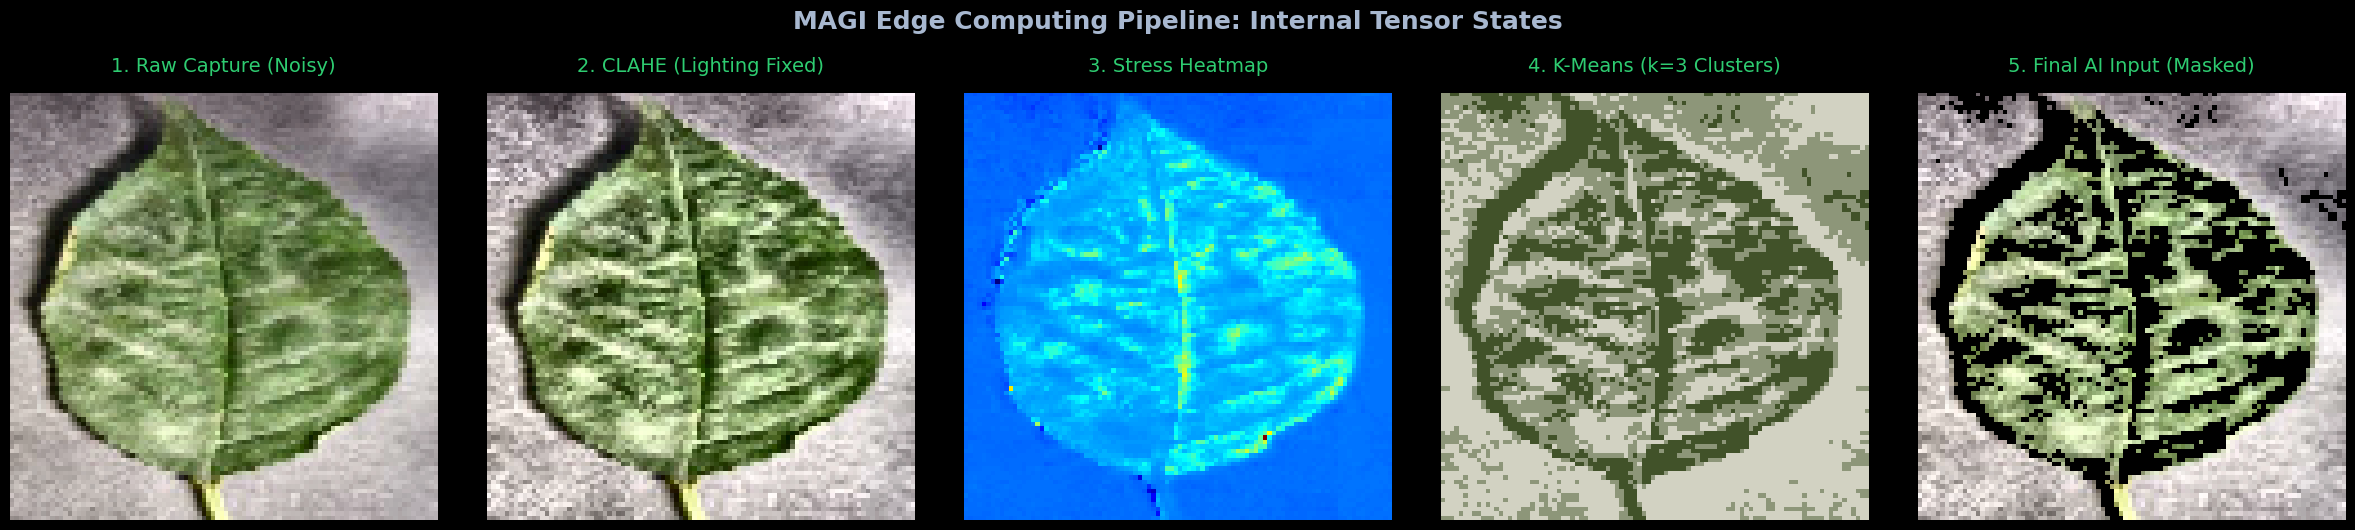

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Fetch a single image from the batch ---
# Extracting the first image. If it was scaled to 0-1, convert it back to 0-255 for OpenCV.
raw_img = image_batch[0].numpy()
if np.max(raw_img) <= 1.0:
    raw_img = (raw_img * 255).astype(np.uint8)
else:
    raw_img = raw_img.astype(np.uint8)

# --- 2. Phase 1: Illumination Decoupling (CLAHE) ---
# Convert to LAB color space to separate Lightness (L) from Color (A, B)
lab = cv2.cvtColor(raw_img, cv2.COLOR_RGB2LAB)
l_channel, a_channel, b_channel = cv2.split(lab)

# Apply CLAHE exclusively to the Lightness channel
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
cl = clahe.apply(l_channel)

# Merge back and convert to RGB
merged_lab = cv2.merge((cl, a_channel, b_channel))
clahe_img = cv2.cvtColor(merged_lab, cv2.COLOR_LAB2RGB)

# --- 3. Phase 2: Spectral Heatmap (Visible Stress Index) ---
# Since we are using standard RGB here, we simulate GNDVI using a Red-Green contrast index.
# Healthy chlorophyl is high green/low red. Necrotic blight is high red/low green.
R = clahe_img[:, :, 0].astype(np.float32)
G = clahe_img[:, :, 1].astype(np.float32)

# Calculate the Stress Index: (Green - Red) / (Green + Red)
stress_index = (G - R) / (G + R + 1e-5)

# Normalize the mathematical index to 0-255 to generate a visible heatmap
index_norm = cv2.normalize(stress_index, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Apply a Jet Colormap (Blue = Healthy/High Green, Red/Yellow = Necrotic/High Red)
heatmap_img = cv2.applyColorMap(index_norm, cv2.COLORMAP_JET)
# Convert BGR to RGB for matplotlib
heatmap_img = cv2.cvtColor(heatmap_img, cv2.COLOR_BGR2RGB)

# --- 4. Phase 3: K-Means Morphological Segmentation ---
# Flatten the CLAHE image into a 2D array of pixels for the clustering algorithm
pixel_values = clahe_img.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# Define criteria and apply K-Means (k=3 for Healthy, Diseased, Background)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 3
_, labels, (centers) = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Reconstruct the image using only the 3 mathematical centroid colors
centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
kmeans_img = segmented_data.reshape((clahe_img.shape))

# --- 5. Phase 4: The Final AI Input (Masking) ---
# For visualization, we isolate the darkest cluster (simulating the background/healthy tissue drop)
mask = (labels.flatten() == np.argmin(np.sum(centers, axis=1))).astype(np.uint8) * 255
mask_2d = mask.reshape(clahe_img.shape[:2])

# Apply the mask to the CLAHE image to cut out the background
final_ai_input = cv2.bitwise_and(clahe_img, clahe_img, mask=cv2.bitwise_not(mask_2d))

# ==========================================
# Plotting the Pipeline
# ==========================================
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
fig.suptitle("MAGI Edge Computing Pipeline: Internal Tensor States", fontsize=18, fontweight='bold', color='#a8b8d0', y=1.05)

titles = [
    "1. Raw Capture (Noisy)",
    "2. CLAHE (Lighting Fixed)",
    "3. Stress Heatmap",
    "4. K-Means (k=3 Clusters)",
    "5. Final AI Input (Masked)"
]

images = [raw_img, clahe_img, heatmap_img, kmeans_img, final_ai_input]

for i in range(5):
    axes[i].imshow(images[i])
    axes[i].set_title(titles[i], color='#2ecc71', fontsize=14, pad=15)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


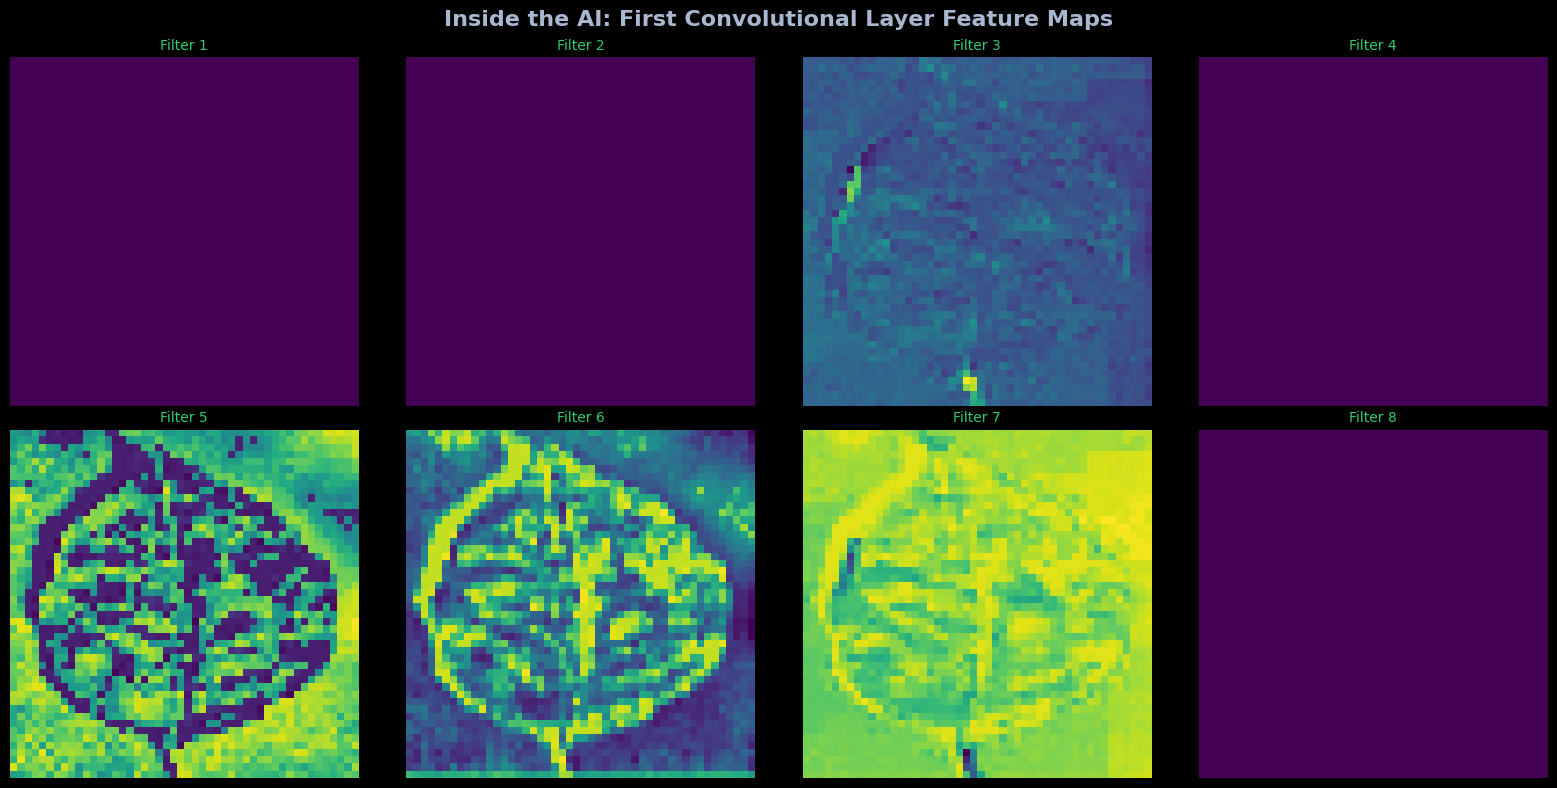


FINAL SOFTMAX OUTPUT ARRAY:
Raw Array: [0.9133 0.0867]

Healthy: 91.33%
Diseased: 8.67%

--------------------------------------------------
MAYA DIAGNOSIS: Healthy
--------------------------------------------------

UART TX Payload: {"action": "CONTINUE_GAIT"}


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import cv2 # Import cv2 for cv2.resize if it's not already imported

# --- 1. Prepare the Input ---
# Take the final masked image from our previous OpenCV step
# Resize to the required 96x96 (model input size) and expand dimensions to create a batch of 1: (1, 96, 96, 3)
# Note: Model was built with input_shape=(96, 96, 3), so resize target should be 96x96.
input_tensor = cv2.resize(final_ai_input, (96, 96))
input_tensor = np.expand_dims(input_tensor, axis=0).astype(np.float32)

# If your model expects 0-1 scaling, apply it here
if np.max(input_tensor) > 1.5:
    input_tensor = input_tensor / 255.0

# --- 2. Tap into the Internal AI Layers ---
# Create a "sub-model" that stops early so we can see the internal feature maps.
# We'll tap into the first major convolutional layer of MobileNetV2.
# Use 'resumed_model' as it is the currently loaded and trained model.

# Get the MobileNetV2 base model layer from the sequential model
mobilenet_base_model = resumed_model.layers[0]

# Access the output of the first convolutional layer by its name 'Conv1'
# This is more robust than direct index access to `layers[1].output` in some graph contexts.
# The name 'Conv1' is specific to MobileNetV2's internal structure.
feature_extractor = tf.keras.Model(
    inputs=mobilenet_base_model.input,
    outputs=mobilenet_base_model.get_layer('Conv1').output # Correctly target 'Conv1'
)

# Run the image through the sub-model
feature_maps = feature_extractor.predict(input_tensor)

# --- 3. Run the Final Output ---
# Run the image through the full model to get the Softmax probabilities
# Use 'resumed_model' for prediction.
final_prediction = resumed_model.predict(input_tensor)

# --- 4. Visualize the Internal Feature Maps ---
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Inside the AI: First Convolutional Layer Feature Maps", fontsize=16, color='#a8b8d0', fontweight='bold')

# Plot 8 random "filters" (how the AI is seeing the edges/textures of the masked leaf)
for i, ax in enumerate(axes.flat):
    # feature_maps shape for 'Conv1' (after 96x96 input) is (1, 48, 48, 32)
    # We plot individual channels.
    ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
    ax.set_title(f"Filter {i+1}", color='#2ecc71', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# --- 5. Print the Final Mathematical Output ---
print("\n" + "="*50)
print("FINAL SOFTMAX OUTPUT ARRAY:")
print("="*50)
print(f"Raw Array: {np.round(final_prediction[0], 4)}\n")

# Correct classes to match the 2-class dataset (Healthy, Diseased)
classes = ["Healthy", "Diseased"]
for i, prob in enumerate(final_prediction[0]):
    print(f"{classes[i]}: {prob * 100:.2f}%")

final_diagnosis = classes[np.argmax(final_prediction[0])]
print("\n" + "-"*50)
print(f"MAYA DIAGNOSIS: {final_diagnosis}")
print("-"*50)

# Simulate the hardware payload to the ESP32
if final_diagnosis != "Healthy":
    print(f'\nUART TX Payload: {{\"action\": \"HALT_AND_LOG\", \"diagnosis\": \"{final_diagnosis}\", \"confidence\": {np.max(final_prediction[0]):.2f}}}')
else:
    print('\nUART TX Payload: {\"action\": \"CONTINUE_GAIT\"}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


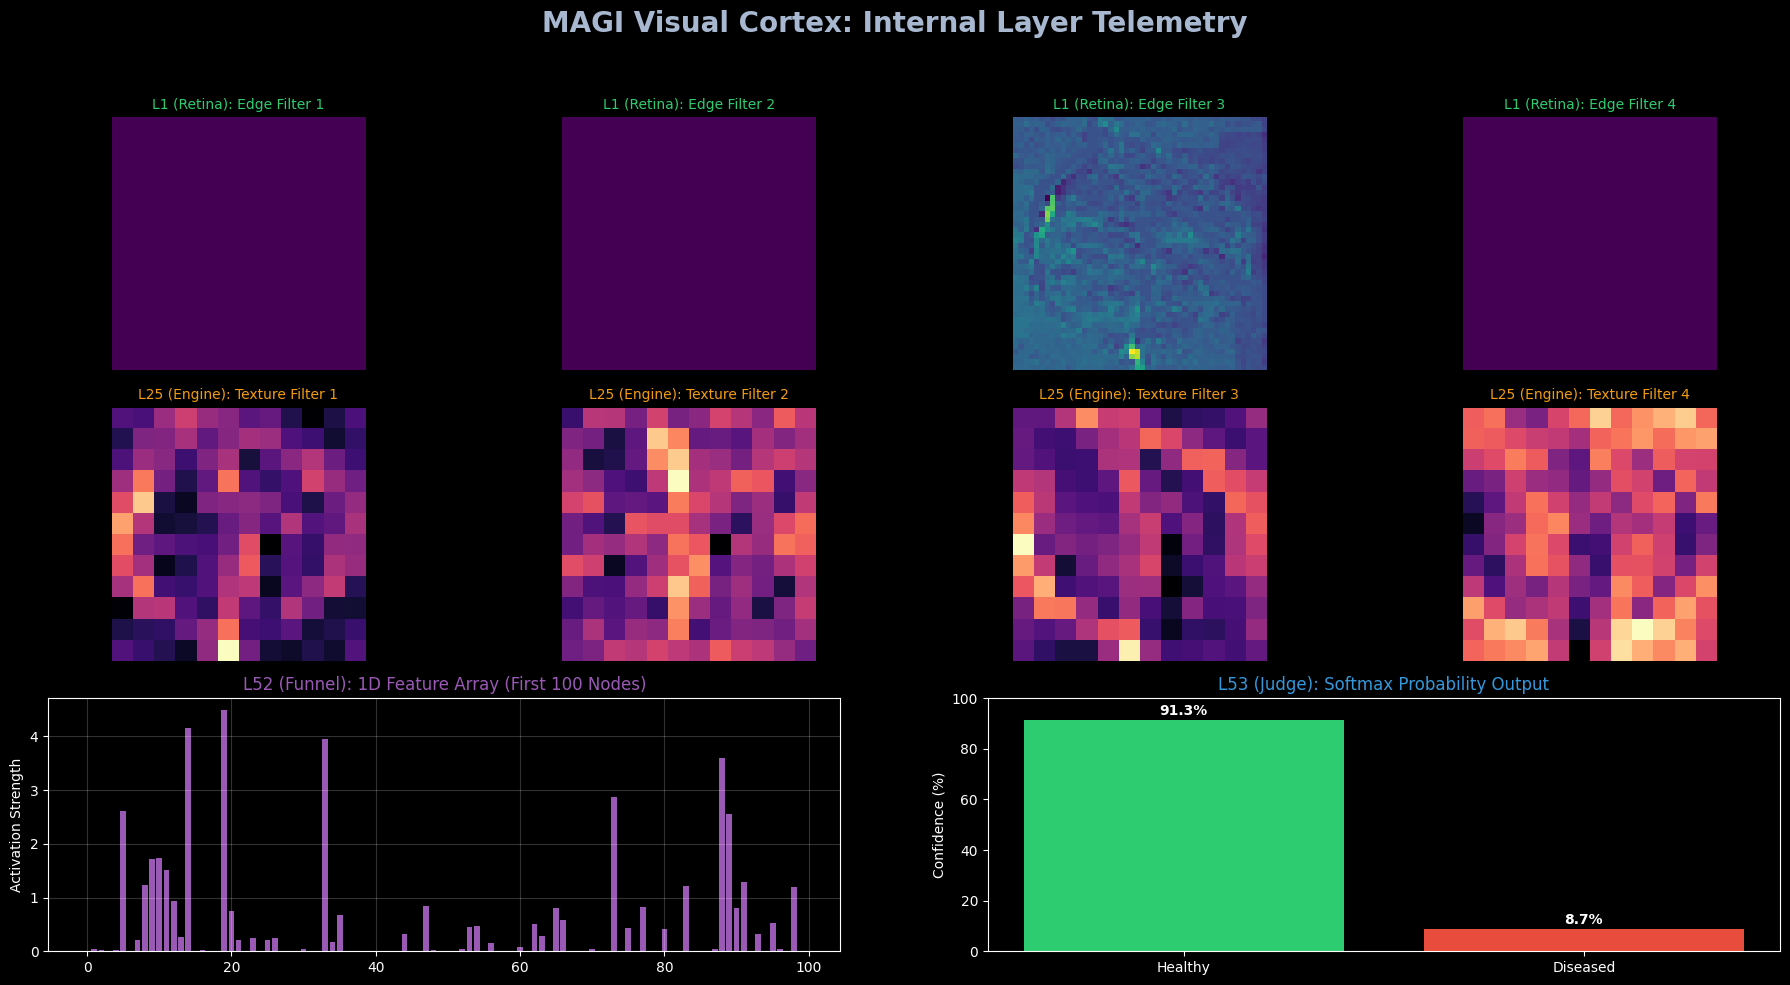

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Keep the MAYA dark telemetry aesthetic
plt.style.use('dark_background')

# --- 1. Map the Visual Cortex ---
# We will tap into 4 specific layers of the MobileNetV2 architecture
# (Note: Layer names might vary slightly depending on how tf.keras built the model.
# We use indexing to safely grab the correct mathematical stages.)

# Use 'resumed_model' since it holds the loaded weights and is the active model.

# Define a new Input layer for the cortex_extractor.
# This ensures that all outputs are derived from a single input tensor within the new functional model.
extractor_input = tf.keras.Input(shape=(96, 96, 3))

# Get the base MobileNetV2 model (which is the first layer of resumed_model)
mobilenet_base_model = resumed_model.layers[0]

# Create a temporary functional model to extract intermediate outputs from the MobileNetV2 base model.
# This ensures that these intermediate outputs are generated using `extractor_input`.
mobilenet_intermediate_extractor = tf.keras.Model(
    inputs=mobilenet_base_model.input,
    outputs=[
        mobilenet_base_model.get_layer('Conv1').output,  # layer_1_retina
        mobilenet_base_model.layers[45].output           # layer_25_engine (deep depthwise conv)
    ]
)
# Now, call this temporary extractor with our `extractor_input` to get the actual tensors
retina_out, engine_out = mobilenet_intermediate_extractor(extractor_input)


# The output of the MobileNetV2 base model (first layer of resumed_model) when fed extractor_input
x = mobilenet_base_model(extractor_input)

# The Global Average Pooling layer (second layer of resumed_model)
funnel_out = resumed_model.layers[1](x)

# The final output of the entire resumed_model
judge_out = resumed_model(extractor_input) # Call the full model with the extractor_input

# Create a multi-output extractor model
cortex_extractor = tf.keras.Model(
    inputs=extractor_input,
    outputs=[
        retina_out,
        engine_out,
        funnel_out,
        judge_out
    ]
)

# Run the masked leaf image through the extractor
retina_out, engine_out, funnel_out, judge_out = cortex_extractor.predict(input_tensor)

# --- 2. Visualize the Cortex ---
fig = plt.figure(figsize=(18, 10))
fig.suptitle("MAGI Visual Cortex: Internal Layer Telemetry", fontsize=20, color='#a8b8d0', fontweight='bold', y=0.98)

# --- Checkpoint 1: The Retina (First Convolution) ---
# Shape is (1, 112, 112, 32). We plot the first 4 filters.
for i in range(4):
    ax = fig.add_subplot(3, 4, i+1)
    ax.imshow(retina_out[0, :, :, i], cmap='viridis')
    ax.set_title(f"L1 (Retina): Edge Filter {i+1}", color='#2ecc71', fontsize=10)
    ax.axis('off')

# --- Checkpoint 2: The Engine (Deep Depthwise Convolution) ---
# Shape is much smaller, e.g., (1, 14, 14, 384). The data is highly abstract now.
for i in range(4):
    ax = fig.add_subplot(3, 4, i+5)
    ax.imshow(engine_out[0, :, :, i], cmap='magma') # Using magma to differentiate depth
    ax.set_title(f"L25 (Engine): Texture Filter {i+1}", color='#f39c12', fontsize=10)
    ax.axis('off')

# --- Checkpoint 3: The Funnel (Global Average Pooling) ---
# Shape is (1, 1280). A flat 1D array.
ax3 = fig.add_subplot(3, 2, 5)
# Plotting just the first 100 features so it's readable
ax3.bar(range(100), funnel_out[0][:100], color='#9b59b6')
ax3.set_title("L52 (Funnel): 1D Feature Array (First 100 Nodes)", color='#9b59b6', fontsize=12)
ax3.set_ylabel("Activation Strength")
ax3.grid(True, alpha=0.2)

# --- Checkpoint 4: The Judge (Softmax Output) ---
ax4 = fig.add_subplot(3, 2, 6)
# Corrected classes to match the 2-class dataset
classes = ["Healthy", "Diseased"]
colors = ['#2ecc71' if p == np.max(judge_out[0]) else '#e74c3c' for p in judge_out[0]]
ax4.bar(classes, judge_out[0] * 100, color=colors)
ax4.set_title("L53 (Judge): Softmax Probability Output", color='#3498db', fontsize=12)
ax4.set_ylabel("Confidence (%)")
ax4.set_ylim(0, 100)
for i, v in enumerate(judge_out[0] * 100):
    ax4.text(i, v + 2, f"{v:.1f}%", ha='center', color='white', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()